In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner

In [20]:
def plot_corner_full(samples):
    fig = corner.corner(
        samples,
        labels=[
            r"$f$",
            r"$\alpha$",
            r"$\mu_x$ (pc)",
            r"$\mu_y$ (pc)",
            r"$\sigma_X$ (pc)",
            r"$\sigma_Y$ (pc)",
            r"$\mu_{v,\rm dw}$",
            r"$\sigma_{v,\rm dw}$",
            r"$\mu_{v,\rm MW}$",
            r"$\sigma_{v,\rm MW}$"
        ],
        show_titles=True,
        title_fmt=".3f",
        quantiles=[0.16, 0.5, 0.84],
        levels=(0.16, 0.5, 0.84),
        color="royalblue",
        fill_contours=True
    )
    plt.show()
    return fig

In [21]:
def log_likelihood(params, x_pc, y_pc, v_obs, delta_v):
    """
    params = [f, alpha, mu_x, mu_y, sigma_x, sigma_y, mu_v_dw, sig_v_dw, mu_v_mw, sig_v_mw]
    x_pc, y_pc：恒星二维空间坐标
    v_obs：观测视线速度
    delta_v：速度观测误差
    """
    f, alpha, mu_x, mu_y, sigma_x, sigma_y, mu_v_dw, sig_v_dw, mu_v_mw, sig_v_mw = params
    range_x, range_y = 10000, 10000
    dx = x_pc - mu_x
    dy = y_pc - mu_y
    x1 = dx * np.cos(alpha) + dy * np.sin(alpha)
    y1 = dy * np.cos(alpha) - dx * np.sin(alpha)
    log_gauss_sp = -np.log(2 * np.pi) - np.log(sigma_x) - np.log(sigma_y) - 0.5 * (x1**2 / sigma_x**2 + y1**2 / sigma_y**2)
    log_bg_sp = -np.log(range_x * range_y)

    mask_missing_v = np.isclose(v_obs, 999.000) & np.isclose(delta_v, 999.000)
    v_obs[mask_missing_v] = 0.0
    delta_v[mask_missing_v] = 9999.0

    sig_tot_dw = np.sqrt(sig_v_dw**2 + delta_v**2)
    log_gauss_v = -0.5 * np.log(2 * np.pi) - np.log(sig_tot_dw) - 0.5 * ((v_obs - mu_v_dw) / sig_tot_dw) ** 2
    sig_tot_mw = np.sqrt(sig_v_mw**2 + delta_v**2)
    log_bg_v = -0.5 * np.log(2 * np.pi) - np.log(sig_tot_mw) - 0.5 * ((v_obs - mu_v_mw) / sig_tot_mw) ** 2

    log_dw_full = log_gauss_sp + log_gauss_v
    log_mw_full = log_bg_sp + log_bg_v
    term_dw_full = np.log(f) + log_dw_full
    term_mw_full = np.log1p(-f) + log_mw_full
    single_total_logp = np.logaddexp(term_dw_full, term_mw_full)

    return np.sum(single_total_logp)

In [22]:
def metropolis_full_param(
    x_pc, y_pc,
    v_obs=None, delta_v=None,
    n_samples=15000,
    f_init=0.5, step_f=0.02,
    alpha_init=0, step_alpha=0.3,
    mu_x_init=0, step_mu_x=5,
    mu_y_init=0, step_mu_y=5,
    sig_x_init=200, step_sig_x=5,
    sig_y_init=100, step_sig_y=5,
    mu_v_dw_init=0, step_mu_v_dw=2,
    sig_v_dw_init=15, step_sig_v_dw=0.5,
    mu_v_mw_init=0, step_mu_v_mw=3,
    sig_v_mw_init=50, step_sig_v_mw=1,
    clip=10000,
    name=""
):
    count_accepted = 0
    count_proposed = 0
    n_col = 11
    chain = np.zeros((n_samples, n_col))

    f0, a0, mx0, my0, sx0, sy0 = f_init, alpha_init, mu_x_init, mu_y_init, sig_x_init, sig_y_init
    mvd0, svd0, mvm0, svm0 = mu_v_dw_init, sig_v_dw_init, mu_v_mw_init, sig_v_mw_init
    init_params = [f0, a0, mx0, my0, sx0, sy0, mvd0, svd0, mvm0, svm0]
    logL0 = log_likelihood(init_params, x_pc, y_pc, v_obs, delta_v)
    chain[0] = [*init_params, logL0]

    param_steps = [step_f, step_alpha, step_mu_x, step_mu_y, step_sig_x, step_sig_y, step_mu_v_dw, step_sig_v_dw, step_mu_v_mw, step_sig_v_mw]

    for i in range(1, n_samples):
        curr_row = chain[i-1]
        curr_params = curr_row[:10].copy()
        logL_curr = curr_row[-1]
        prop_vals = curr_params + np.random.normal(0, param_steps, size=10)
        f_p, a_p, mx_p, my_p, sx_p, sy_p, mvd_p, svd_p, mvm_p, svm_p = prop_vals
        count_proposed += 1

        valid = True
        if not (0 < f_p < 1): valid = False
        if not (0 <= a_p <= np.pi): valid = False
        if not (20 <= sx_p <= 1200 and 20 <= sy_p <= 1200): valid = False
        if not (-300 <= mvd_p <= 300 and -300 <= mvm_p <= 300): valid = False
        if not (0 < svd_p <= 40): valid = False
        if not (0 <= svm_p <= 120): valid = False

        if not valid:
            new_params = curr_params
            new_logL = logL_curr
        else:
            logL_prop = log_likelihood(prop_vals, x_pc, y_pc, v_obs, delta_v)
            log_ratio = logL_prop - logL_curr
            if np.log(np.random.rand()) < log_ratio:
                new_params = prop_vals
                new_logL = logL_prop
                count_accepted += 1
            else:
                new_params = curr_params
                new_logL = logL_curr

        chain[i] = [*new_params, new_logL]

    burn_in = chain[clip:]
    if count_proposed == 0:
        print(f"总采样 {n_samples}, 无有效proposal，所有参数提议均超出边界约束")
    else:
        print(f"总采样 {n_samples}, 有效proposal {count_proposed}, 接受次数 {count_accepted}, 接受率 {count_accepted/count_proposed:.3f}")
    df_chain = pd.DataFrame(burn_in, columns=["f","alpha","mu_x","mu_y","sig_x","sig_y","mu_v_dw","sig_v_dw","mu_v_mw","sig_v_mw","logL"])
    df_chain.to_csv(f"{name}_mcmc_10params.csv", index=False)
    return burn_in

In [23]:
def main(name,
        n_samples=50000,
        f_init=0.1, step_f=0.005,
        alpha_init=1.8, step_alpha=0.05,
        mu_x_init=30, step_mu_x=10,
        mu_y_init=-10, step_mu_y=10,
        sig_x_init=300, step_sig_x=10,
        sig_y_init=200, step_sig_y=7,
        mu_v_dw_init=0, step_mu_v_dw=6,
        sig_v_dw_init=15, step_sig_v_dw=3,
        mu_v_mw_init=6, step_mu_v_mw=4,
        sig_v_mw_init=80, step_sig_v_mw=2.5,
        clip=10000,):
    df = pd.read_csv(name)
    x_pc = df["X_pc"].values
    y_pc = df["Y_pc"].values
    v_obs = df["vr"].values
    delta_v = df["d_vr"].values

    burn_chain = metropolis_full_param(
        x_pc=x_pc,
        y_pc=y_pc,
        v_obs=v_obs,
        delta_v=delta_v,
        n_samples=n_samples,
        f_init=f_init, step_f=step_f,
        alpha_init=alpha_init, step_alpha=step_alpha,
        mu_x_init=mu_x_init, step_mu_x=step_mu_x,
        mu_y_init=mu_y_init, step_mu_y=step_mu_y,
        sig_x_init=sig_x_init, step_sig_x=step_sig_x,
        sig_y_init=sig_y_init, step_sig_y=step_sig_y,
        mu_v_dw_init=mu_v_dw_init, step_mu_v_dw=step_mu_v_dw,
        sig_v_dw_init=sig_v_dw_init, step_sig_v_dw=step_sig_v_dw,
        mu_v_mw_init=mu_v_mw_init, step_mu_v_mw=step_mu_v_mw,
        sig_v_mw_init=sig_v_mw_init, step_sig_v_mw=step_sig_v_mw,
        clip=clip,
        name=name.split(".")[0]
    )

    params_name = ["f","alpha","mu_x","mu_y","sig_x","sig_y","mu_v_dw","sig_v_dw","mu_v_mw","sig_v_mw"]
    median_vals = np.median(burn_chain[:, :-1], axis=0)
    for name, val in zip(params_name, median_vals):
        print(f"{name} 中位数拟合值: {val:.4f}")
    plot_corner_full(burn_chain[:, :-1])

总采样 50000, 有效proposal 49999, 接受次数 11851, 接受率 0.237
f 中位数拟合值: 0.0879
alpha 中位数拟合值: 1.8170
mu_x 中位数拟合值: 34.7947
mu_y 中位数拟合值: -14.9336
sig_x 中位数拟合值: 429.4282
sig_y 中位数拟合值: 212.9753
mu_v_dw 中位数拟合值: -23.0467
sig_v_dw 中位数拟合值: 19.3304
mu_v_mw 中位数拟合值: 6.8764
sig_v_mw 中位数拟合值: 90.4215


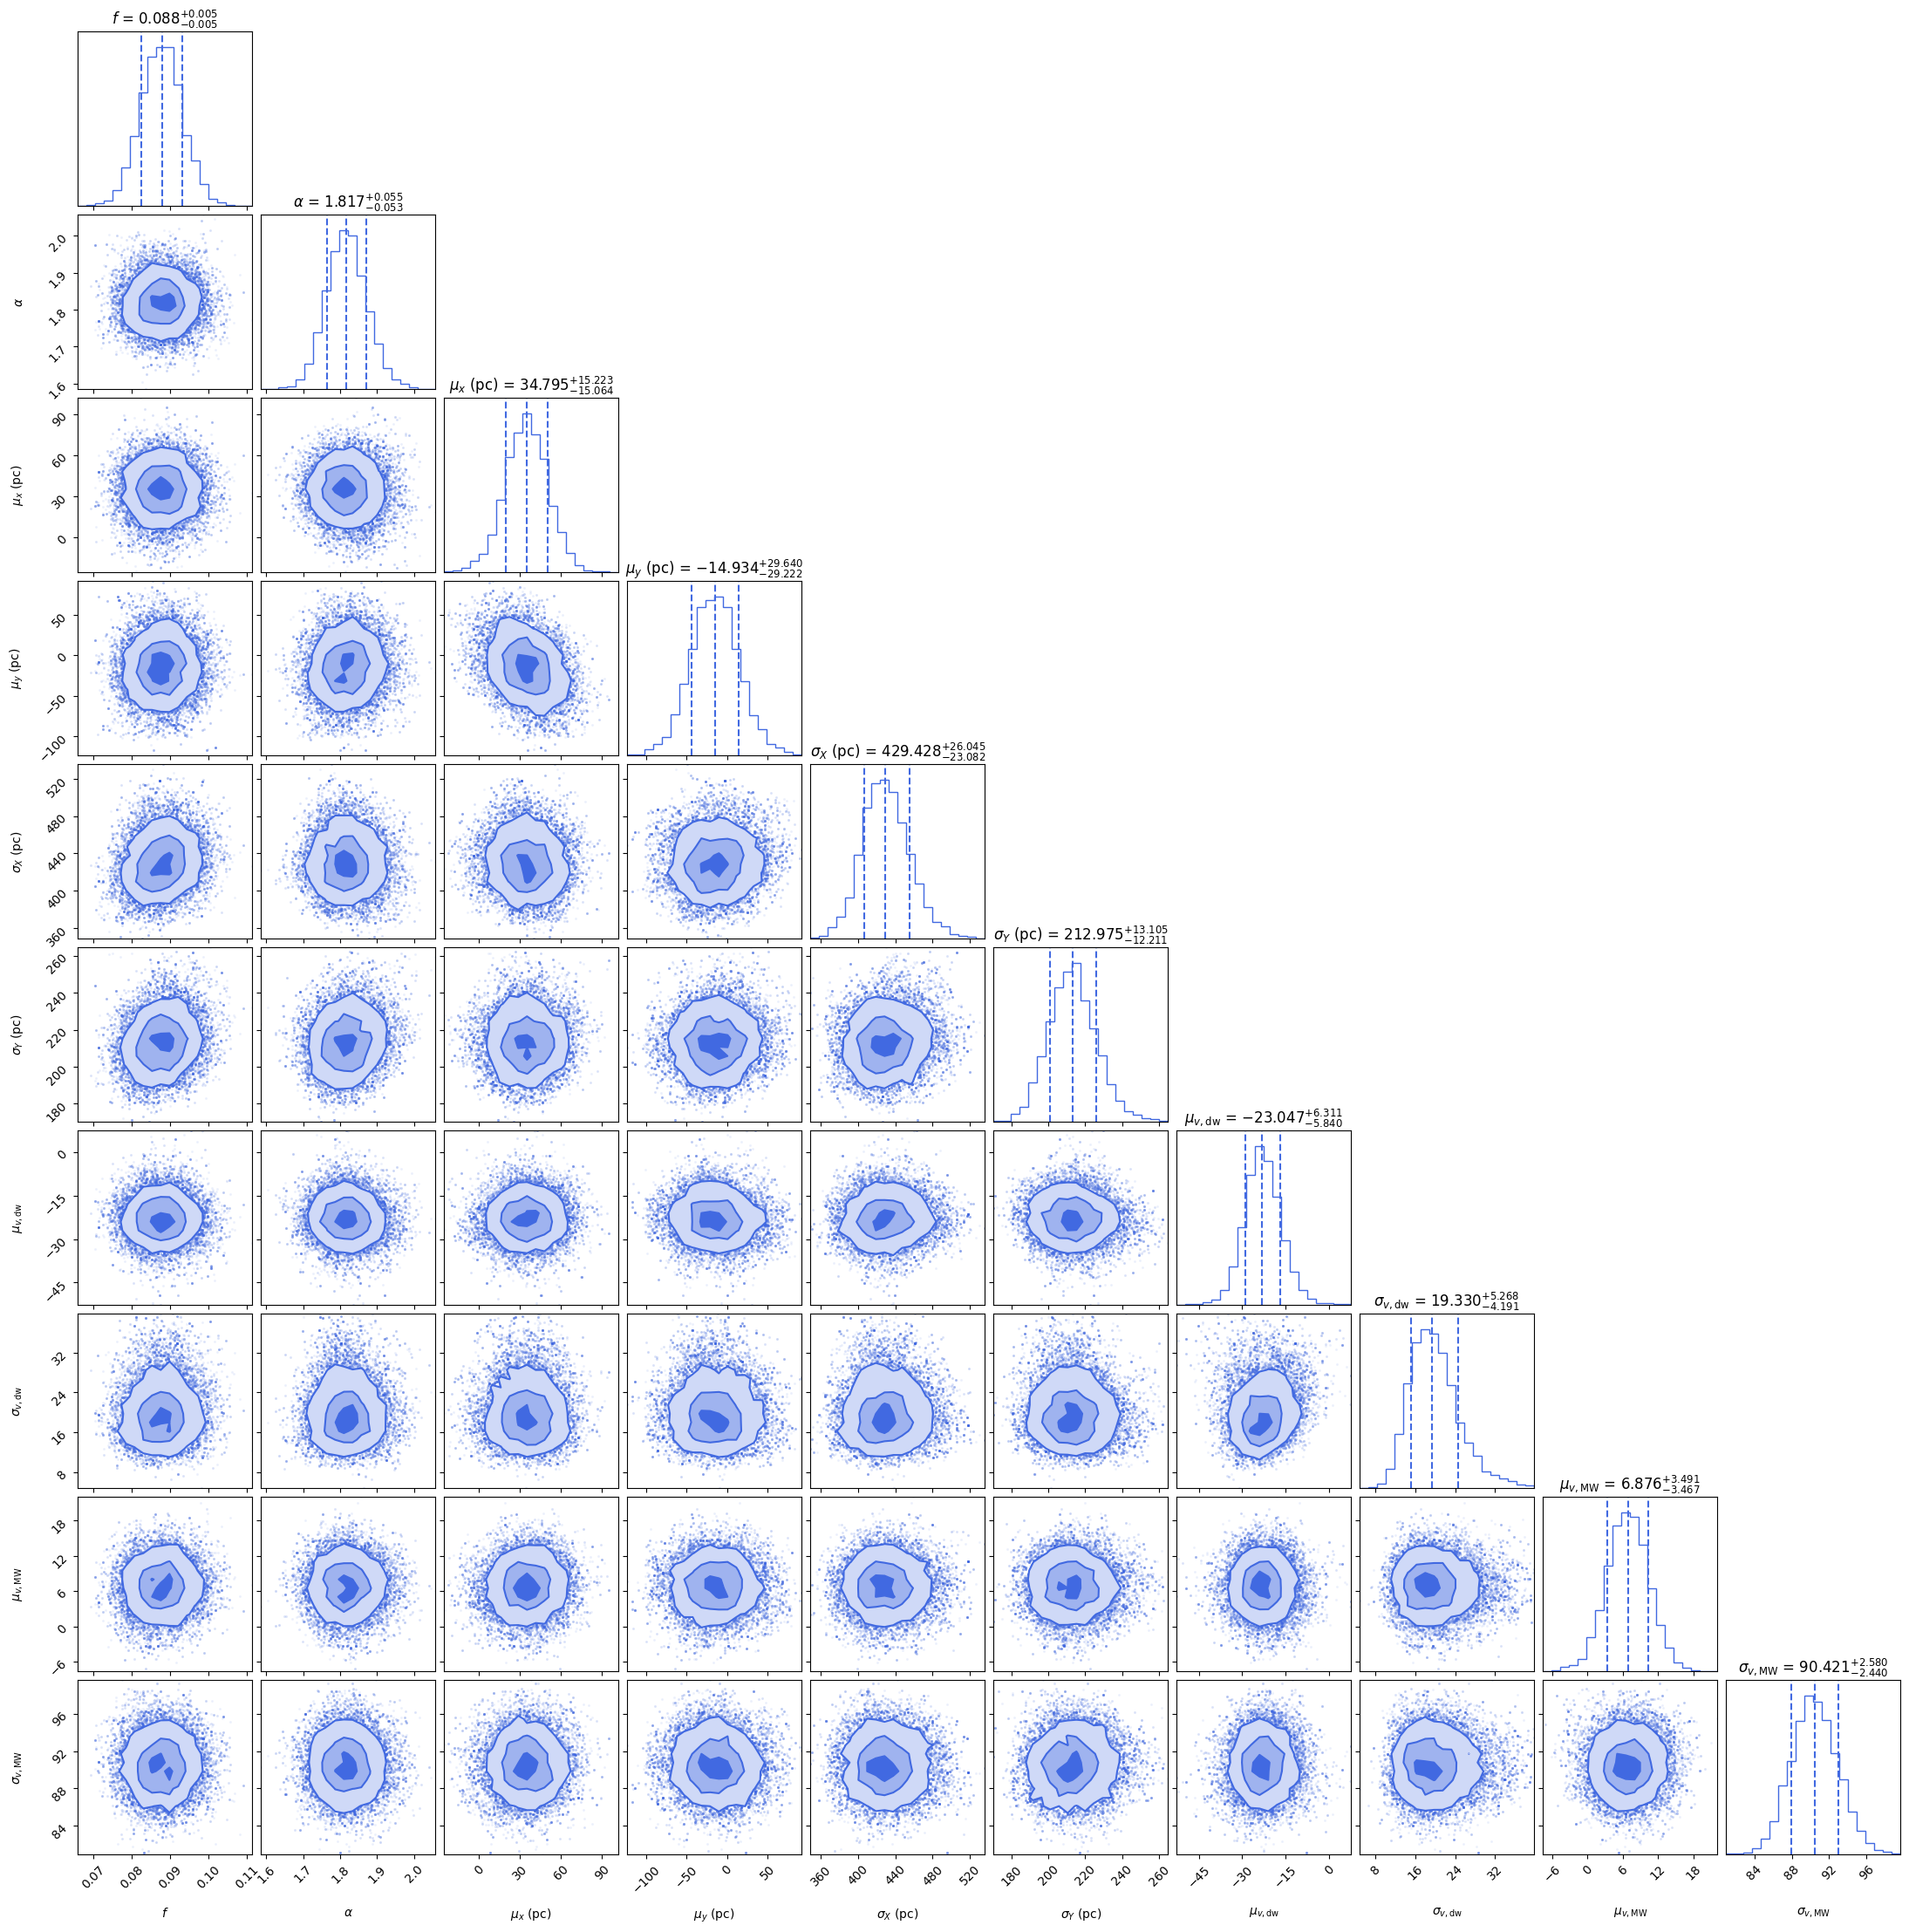

In [24]:
main("data/Dwarfs/Dwarf_03.csv",
        n_samples=50000,
        f_init=0.1, step_f=0.005,
        alpha_init=1.8, step_alpha=0.05,
        mu_x_init=30, step_mu_x=10,
        mu_y_init=-10, step_mu_y=10,
        sig_x_init=300, step_sig_x=10,
        sig_y_init=200, step_sig_y=7,
        mu_v_dw_init=0, step_mu_v_dw=6,
        sig_v_dw_init=15, step_sig_v_dw=3,
        mu_v_mw_init=6, step_mu_v_mw=4,
        sig_v_mw_init=80, step_sig_v_mw=2.5,
        clip=5000,)